# Luna Marcelo — Aprendizaje Profundo — TP1 — Cohorte 24

Notebook de entrega según consigna del curso (desarrollo en celdas, compatible con Google Colab).

La siguiente celda **importa** las bibliotecas base: **NumPy**, **SciPy** y **Matplotlib** (gráficos de la consigna). **Resultado esperado:** ejecución sin errores y mensajes de versión útiles para reproducibilidad en Colab.

## Consigna 

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para los 3 learning rates. Las 3 gráficas deben estar en el mismo plot para que la comparación visual sea más fácil.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [11]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", mpl.__version__)

NumPy: 2.0.2
SciPy: 1.16.3
Matplotlib: 3.10.0


### Hiperparámetros para comparativas

Acuerdo para los experimentos del TP (gradiente descendente y, más adelante, otros optimizadores): **100 épocas** y tres **tasas de aprendizaje** \(0{,}1\), \(0{,}01\) y \(0{,}001\). Conviene definirlos como **variables en una sola celda** para no repetir números en el código, poder ajustarlos después sin buscar literales y dejar constancia en el notebook de qué valores se usaron.

La siguiente celda define esos valores y la **semilla** `SEMILLA_PARAMETROS_INICIALES` para reproducir siempre el mismo \((w_0,b_0)\) compartido; **resultado esperado:** constantes listas para bucles y documentación de la entrega.

In [12]:
# Comparativa según consigna (modificar solo aquí si hace falta otro experimento)
EPOCAS_COMPARATIVA = 100
TASAS_APRENDIZAJE = (0.1, 0.01, 0.001)
# Misma semilla => mismo (w0, b0) en todos los optimizadores y corridas comparables
SEMILLA_PARAMETROS_INICIALES = 0

print(f"Épocas: {EPOCAS_COMPARATIVA}")
print(f"Tasas de aprendizaje: {TASAS_APRENDIZAJE}")
print(f"Semilla para w0, b0: {SEMILLA_PARAMETROS_INICIALES}")

Épocas: 100
Tasas de aprendizaje: (0.1, 0.01, 0.001)
Semilla para w0, b0: 0


### Red neuronal de una sola conexión

La siguiente celda define la **capa** con un único peso \(w\) y sesgo \(b\): primero \(z = w x + b\) (vectorizado sobre \(m\) muestras), luego \(\hat{y} = \tanh(z)\). También define el **error cuadrático medio** \(J(w,b)=\frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)^2\).

**Resultado esperado:** funciones reutilizables (`preactivacion`, `forward`, `coste`, `inicializar_parametros_aleatorios`) y vectores de datos de juguete `_x`, `_y`. Los valores iniciales \(w_0\) y \(b_0\) compartidos se fijan **después**, en la celda dedicada, para que todos los optimizadores partan del mismo punto.

In [13]:
def preactivacion(x: np.ndarray, w: float, b: float) -> np.ndarray:
    """Calcula z = w * x + b para cada muestra (x puede ser vector de forma (m,))."""
    x = np.asarray(x, dtype=float)
    return w * x + b


def activacion_tanh(z: np.ndarray) -> np.ndarray:
    """Aplica la tangente hiperbólica elemento a elemento (hat{y} = tanh(z))."""
    z = np.asarray(z, dtype=float)
    # NumPy proporciona tanh vectorizado compatible con el runtime de SciPy/Colab.
    return np.tanh(z)


def forward(x: np.ndarray, w: float, b: float) -> np.ndarray:
    """Propagación hacia adelante: devuelve hat{y} = tanh(w * x + b)."""
    z = preactivacion(x, w, b)
    return activacion_tanh(z)


def coste(y_hat: np.ndarray, y: np.ndarray) -> float:
    """
    Error cuadrático medio: J = (1/m) * sum_i (hat{y}_i - y_i)^2.
    """
    y_hat = np.asarray(y_hat, dtype=float)
    y = np.asarray(y, dtype=float)
    m = y_hat.size
    if m == 0:
        raise ValueError("Se necesita al menos una muestra (m >= 1).")
    return float(np.mean((y_hat - y) ** 2))


def coste_parametros(x: np.ndarray, y: np.ndarray, w: float, b: float) -> float:
    """J(w, b) usando los datos (x, y) y los parámetros actuales."""
    return coste(forward(x, w, b), y)


def inicializar_parametros_aleatorios() -> tuple[float, float]:
    """Inicializa w y b con distribución normal estándar (consigna: np.random.randn())."""
    return float(np.random.randn()), float(np.random.randn())


# Datos de juguete para pruebas y entrenamientos de ejemplo (mismo conjunto en todo el notebook)
_x = np.array([-1.0, 0.0, 1.0])
_y = np.array([0.2, 0.5, -0.3])

### Parámetros iniciales \(w_0\) y \(b_0\) compartidos

Para comparar optimizadores de forma **consistente**, todos deben partir del **mismo** punto \((w_0,b_0)\). La siguiente celda usa `SEMILLA_PARAMETROS_INICIALES` y `inicializar_parametros_aleatorios()` para definir **`W_INICIAL`** y **`B_INICIAL`** una sola vez; más adelante cada optimizador los recibe como `w_inicial` y `b_inicial`.

**Resultado esperado:** valores impresos de `W_INICIAL`, `B_INICIAL` y una comprobación rápida de **forward** y **coste** con esos parámetros sobre `_x`, `_y`.

In [14]:
np.random.seed(SEMILLA_PARAMETROS_INICIALES)
W_INICIAL, B_INICIAL = inicializar_parametros_aleatorios()
print("w0, b0 compartidos (usar en todos los optimizadores):", W_INICIAL, B_INICIAL)

_z = preactivacion(_x, W_INICIAL, B_INICIAL)
_y_hat = forward(_x, W_INICIAL, B_INICIAL)
_J = coste_parametros(_x, _y, W_INICIAL, B_INICIAL)
print("z =", _z)
print("hat{y} =", _y_hat)
print("J(w0, b0) =", _J)

w0, b0 compartidos (usar en todos los optimizadores): 1.764052345967664 0.4001572083672233
z = [-1.36389514  0.40015721  2.16420955]
hat{y} = [-0.87729341  0.38008347  0.97396658]
J(w0, b0) = 0.9326439683651063


### Gradiente descendente sobre \(J(w,b)\)

La siguiente celda implementa el **gradiente** de \(J\) respecto de \(w\) y \(b\) para \(\hat{y}=\tanh(wx+b)\) y costo **MSE**: usando \(\frac{\partial \hat{y}}{\partial z}=1-\hat{y}^2\) y la actualización \(w \leftarrow w - \eta \frac{\partial J}{\partial w}\), \(b \leftarrow b - \eta \frac{\partial J}{\partial b}\) (batch completo en cada época).

**Resultado esperado:** funciones `gradiente` y `entrenar_gradiente_descendente` (si no se pasan \(w\) y \(b\) iniciales, se obtienen con `inicializar_parametros_aleatorios`); una **corrida** por cada \(\eta\) que guarda el historial de \(J\) en `historiales_J_gd` y muestra \(J\) inicial/final por pantalla (la figura \(J\) vs época está en la siguiente sección).

In [15]:
def gradiente(x: np.ndarray, y: np.ndarray, w: float, b: float) -> tuple[float, float]:
    """
    Gradiente de J(w, b) para MSE y activación tanh (derivada respecto de z: 1 - hat{y}^2).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = x.size
    if m == 0:
        raise ValueError("Se necesita al menos una muestra (m >= 1).")

    y_hat = forward(x, w, b)
    residual = y_hat - y
    d_tanh = 1.0 - y_hat**2
    # factor por muestra: (2/m) * (hat{y}_i - y_i) * (1 - hat{y}_i^2)
    factor = (2.0 / m) * residual * d_tanh
    grad_w = float(np.dot(factor, x))
    grad_b = float(np.sum(factor))
    return grad_w, grad_b


def entrenar_gradiente_descendente(
    x: np.ndarray,
    y: np.ndarray,
    tasa_aprendizaje: float,
    epocas: int,
    w_inicial: float | None = None,
    b_inicial: float | None = None,
    semilla: int | None = None,
) -> tuple[float, float, list[float]]:
    """
    Minimiza J(w, b) con gradiente descendente (todo el batch por época).
    Si w_inicial y b_inicial son None, se inicializan con inicializar_parametros_aleatorios() (np.random.randn).
    Para comparar con otros optimizadores, pasar siempre el mismo par (p. ej. W_INICIAL, B_INICIAL).
    Devuelve (w, b, historial_J) donde historial_J[k] es el costo al inicio de la época k.
    """
    if semilla is not None:
        np.random.seed(semilla)

    if w_inicial is None and b_inicial is None:
        w, b = inicializar_parametros_aleatorios()
    elif w_inicial is None:
        w, b = float(np.random.randn()), float(b_inicial)
    elif b_inicial is None:
        w, b = float(w_inicial), float(np.random.randn())
    else:
        w, b = float(w_inicial), float(b_inicial)

    historial_J: list[float] = []
    for _ in range(epocas):
        historial_J.append(coste_parametros(x, y, w, b))
        g_w, g_b = gradiente(x, y, w, b)
        w -= tasa_aprendizaje * g_w
        b -= tasa_aprendizaje * g_b

    return w, b, historial_J


# --- GD por cada η: mismos W_INICIAL, B_INICIAL; historiales para el gráfico ---
historiales_J_gd: dict[float, list[float]] = {}
for _eta in TASAS_APRENDIZAJE:
    _final_w, _final_b, _hist = entrenar_gradiente_descendente(
        _x,
        _y,
        tasa_aprendizaje=_eta,
        epocas=EPOCAS_COMPARATIVA,
        w_inicial=W_INICIAL,
        b_inicial=B_INICIAL,
        semilla=None,
    )
    historiales_J_gd[_eta] = _hist
    _J_fin = coste_parametros(_x, _y, _final_w, _final_b)
    print(f"η = {_eta:g} | J inicio (época 0) = {_hist[0]:.6f} | J final = {_J_fin:.6f} | w, b = {_final_w:.6f}, {_final_b:.6f}")

η = 0.1 | J inicio (época 0) = 0.932644 | J final = 0.064864 | w, b = -0.274597, 0.149960
η = 0.01 | J inicio (época 0) = 0.932644 | J final = 0.814063 | w, b = 1.490722, 0.604502
η = 0.001 | J inicio (época 0) = 0.932644 | J final = 0.924430 | w, b = 1.742620, 0.419180


### Gráfico: costo \(J(w,b)\) vs número de época (GD)

La siguiente celda dibuja en **un solo gráfico** el historial de \(J\) frente al índice de época para cada **learning rate** en `TASAS_APRENDIZAJE`, usando los datos guardados en `historiales_J_gd` tras entrenar con gradiente descendente.

**Resultado esperado:** una figura con tres curvas y leyenda (ejecución previa de la celda de entrenamiento GD obligatoria).

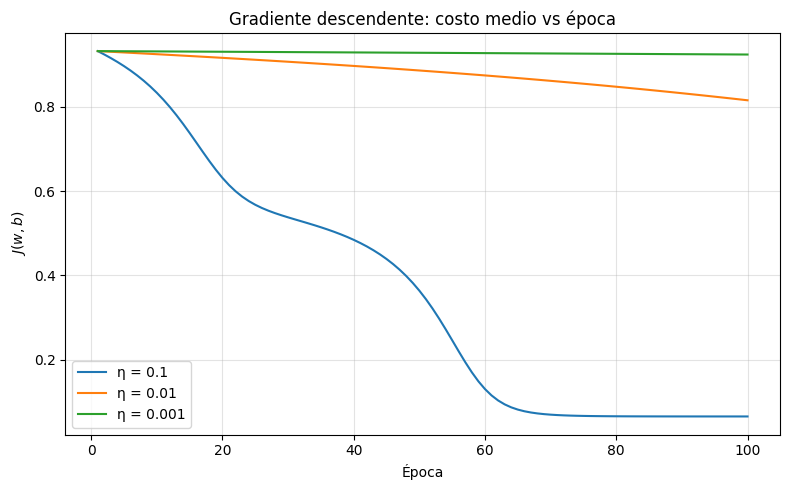

In [16]:
# Si aparece "plt is not defined", ejecutar antes la celda de imports (numpy + matplotlib).
import matplotlib.pyplot as plt
import numpy as np

epocas_eje = np.arange(1, EPOCAS_COMPARATIVA + 1)

plt.figure(figsize=(8, 5))
for _eta in TASAS_APRENDIZAJE:
    plt.plot(epocas_eje, historiales_J_gd[_eta], label=f"η = {_eta:g}")

plt.xlabel("Época")
plt.ylabel(r"$J(w,b)$")
plt.title("Gradiente descendente: costo medio vs época")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()